In [20]:
import pandas as pd
import psychrolib

[1e-07, 0.006213982889463476, 0.006213982889463476, 0.005959709098199538, 0.005522721040231987, 0.006213982889463476, 0.005959709098199538, 0.00575496369542749, 0.00665955778433897, 0.00695283456012741, 0.0069270984169425304, 0.007502212061711614, 0.007209479970661724, 0.007209479970661724, 0.007209479970661724, 0.0069270984169425304, 0.006449288584682134, 0.006173356400409863, 0.005774965165060642, 0.006173356400409863, 0.0059630404543902695, 0.005959709098199538, 0.005959709098199538, 0.0059630404543902695, 0.005538814212385817, 0.005538814212385817, 0.005538814212385817, 0.005524373302715132, 0.005524373302715132, 0.005524373302715132, 0.005538814212385817, 0.0053365606674327945, 0.0053365606674327945, 0.0053365606674327945, 0.0053365606674327945, 0.0053365606674327945, 0.005538814212385817, 0.005538814212385817, 0.0057191286212790555, 0.005959709098199538, 0.006213982889463476, 0.006213982889463476, 0.006213982889463476, 0.00575496369542749, 0.005517584061323754, 0.0052889947122285

<AxesSubplot: xlabel='Step'>

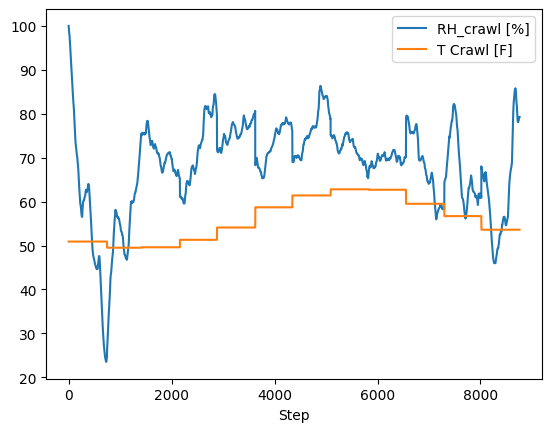

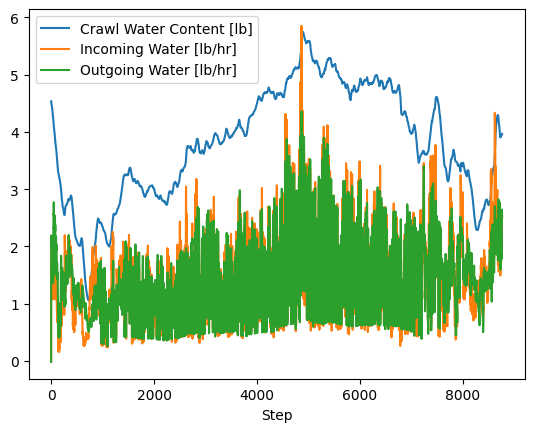

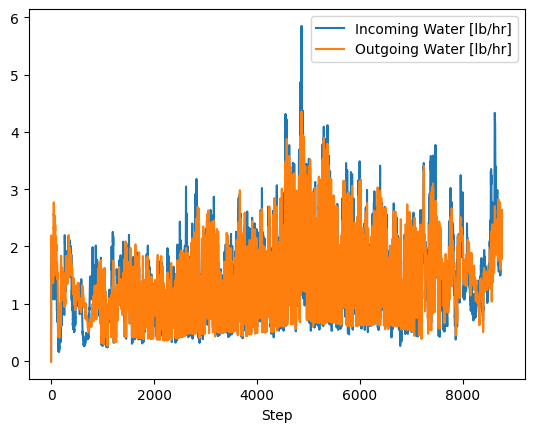

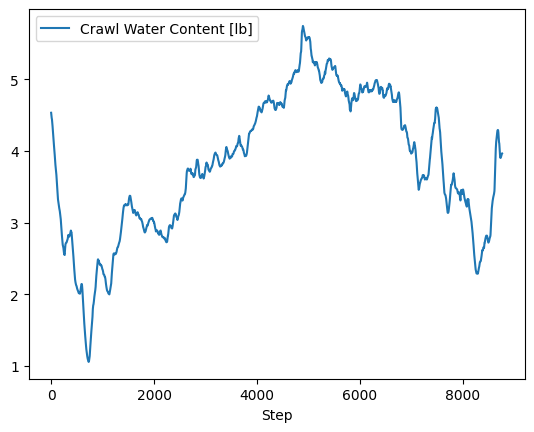

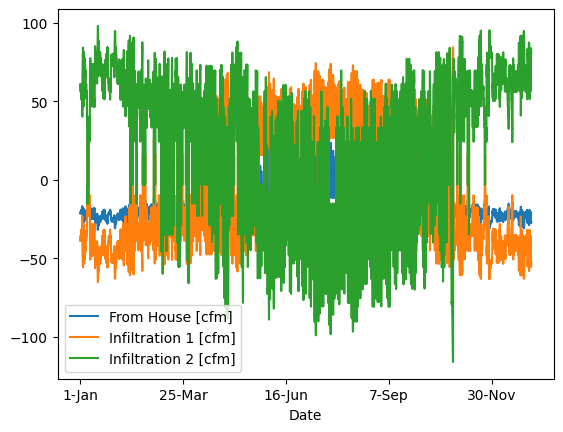

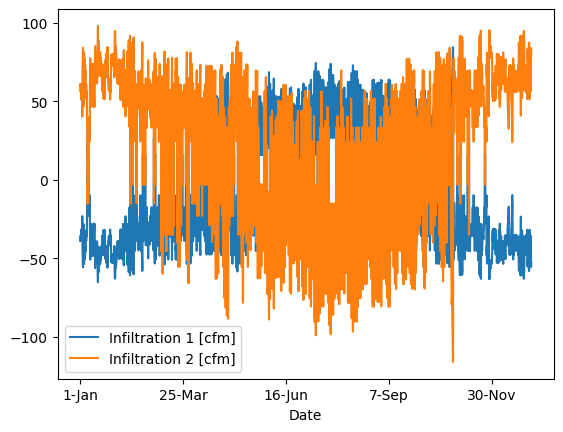

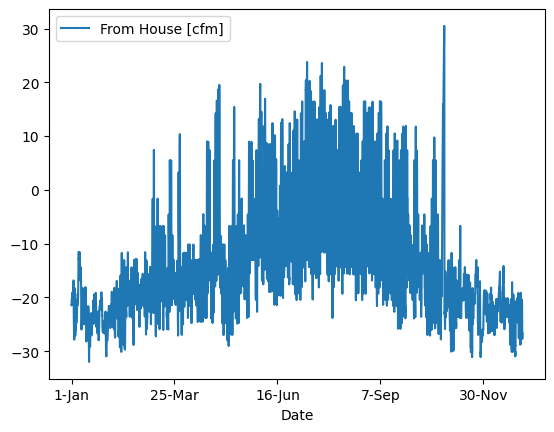

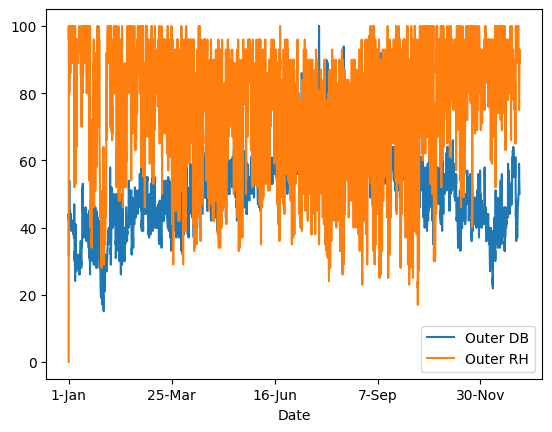

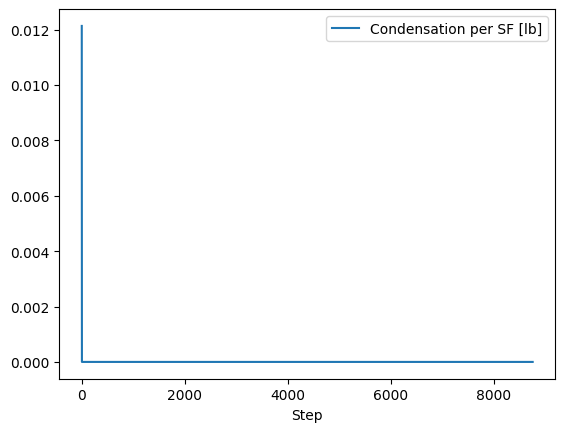

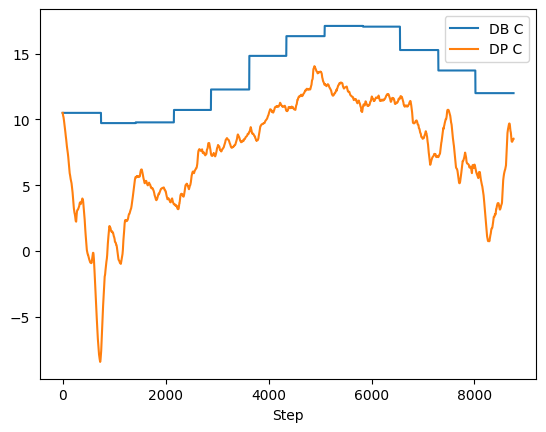

In [24]:
df = pd.read_csv("C:/Users/amitc_crl/Downloads/2743 Hygro CONTAM - 2838.csv")

df.head()

psychrolib.SetUnitSystem(psychrolib.IP)

pressure = psychrolib.GetStandardAtmPressure(580)
hr_init = 0.01
crawl_volume = 7500
crawl_surface_area = (2*2353) + (230*2)


DB_out = list(df['Outer DB'])
RH_out = list(df['Outer RH'])

HR_out = []

for step in range(len(DB_out)):
    HR = psychrolib.GetHumRatioFromRelHum(DB_out[step], (RH_out[step]*0.01), pressure)
    HR_out.append(HR)

print(HR_out)


DB_in = list(df['Indoor DB'])
RH_in = list(df['Indoor RH'])

HR_in = []

for step in range(len(DB_in)):
    HR = psychrolib.GetHumRatioFromRelHum(DB_in[step], (RH_in[step]*0.01), pressure)
    HR_in.append(HR)

print(HR_in)


inf_flow1 = list(df['Infiltration 1 [cfm]'])
inf_flow2 = list(df['Infiltration 2 [cfm]'])
house_flow = list(df['From House [cfm]'])
DB_crawl = list(df['Avg Crawl DB'])




HR_crawl = []
in_HR= []
out_HR = []
RH_crawl = []
DP_crawl = []
condensation_list = []
DP_C = []
DB_C = []


for step in range(len(DB_in)):
    if inf_flow1[step] >= 0:
        inf_flow1_step = inf_flow1[step]*HR_out[step]
    else:
        inf_flow1_step = 0

    if inf_flow2[step] >=0:
        inf_flow2_step = inf_flow2[step]*HR_out[step]
    else:
        inf_flow2_step = 0
    
    if house_flow[step] >= 0:
       house_flow_step =house_flow[step]*HR_in[step]
    else:
       house_flow_step = 0

    incoming_HR = (inf_flow1_step + inf_flow2_step + house_flow_step)
    
    if inf_flow1[step] < 0:
        inf_flow1_step_out = inf_flow1[step]*hr_init
    else:
        inf_flow1_step_out = 0

    if inf_flow2[step] < 0:
        inf_flow2_step_out = inf_flow2[step]*hr_init
    else:
        inf_flow2_step_out = 0
    
    if house_flow[step] < 0:
       house_flow_step_out =house_flow[step]*hr_init
    else:
       house_flow_step_out = 0

    outgoing_HR = (inf_flow1_step_out + inf_flow2_step_out + house_flow_step_out)

    hr_crawl1 = ((crawl_volume*hr_init) + incoming_HR + outgoing_HR)/(crawl_volume)

    if hr_crawl1 < 0:
        hr_crawl1=0
    rh_crawl = ((psychrolib.GetRelHumFromHumRatio(DB_crawl[step],hr_crawl1,pressure))*100)
    DB_C.append((DB_crawl[step] - 32) * (5/9))
    

    if rh_crawl <= 100:
        dp_crawl = psychrolib.GetTDewPointFromRelHum(DB_crawl[step],(rh_crawl * 0.01))
        condensation_list.append(0)
        RH_crawl.append(rh_crawl)
        HR_crawl.append(hr_crawl1*crawl_volume*0.075)
        in_HR.append(incoming_HR*0.075*60)
        out_HR.append(-1*outgoing_HR*0.075*60)
        DP_crawl.append(dp_crawl)
        DP_C.append((dp_crawl - 32) * (5/9))

        hr_init = hr_crawl1

    if rh_crawl > 100:
        rh_crawl = 100
        hr_crawl = psychrolib.GetHumRatioFromRelHum(DB_crawl[step],(rh_crawl * 0.01),pressure)
        outgoing_HR = (((inf_flow[step]) + (house_flow[step])) * hr_crawl)
        condensation = ((hr_crawl1-hr_crawl) * 60 * 0.075 * crawl_volume) / crawl_surface_area
        dp_crawl = psychrolib.GetTDewPointFromRelHum(DB_crawl[step],(rh_crawl * 0.01))


        condensation_list.append(condensation)
        RH_crawl.append(rh_crawl)
        HR_crawl.append(hr_crawl*crawl_volume*0.075)
        in_HR.append(incoming_HR*0.075*60)
        out_HR.append(-1*outgoing_HR*0.075*60)
        DP_crawl.append(dp_crawl)
        DP_C.append((dp_crawl - 32) * (5/9))

        hr_init = hr_crawl
    

print(HR_crawl)

# DB_crawl = list(df['Avg Crawl DB [°F]'])

# RH_crawl = []

# for step in range(len(DB_in)):
#     rh_crawl = ((psychrolib.GetRelHumFromHumRatio(DB_crawl[step],HR_crawl[step],pressure))*100)
#     RH_crawl.append(rh_crawl)

print(len(RH_crawl))
print(len(list(range(0,8761,1))))

d={'T Crawl [F]':DB_crawl,
   'Crawl Water Content [lb]':HR_crawl,
   'Crawl Dry Bulb F':DB_crawl,
   'Crawl DP F':DP_crawl,
   'DB C':DB_C,
   'DP C':DP_C,
   'RH_crawl [%]':RH_crawl,
   'Incoming Water [lb/hr]':in_HR,
   'Outgoing Water [lb/hr]':out_HR,
   'Condensation per SF [lb]':condensation_list,
   'Step':(list(range(0,8760,1)))}

df2 = pd.DataFrame.from_dict(d)

df2.head()

df2.to_csv('RH crawl output 2838.csv')

df2.plot(x='Step', y=['RH_crawl [%]','T Crawl [F]'] , kind='line')
df2.plot(x='Step', y=['Crawl Water Content [lb]','Incoming Water [lb/hr]','Outgoing Water [lb/hr]'] , kind='line')
df2.plot(x='Step', y=['Incoming Water [lb/hr]','Outgoing Water [lb/hr]'] , kind='line')
df2.plot(x='Step', y='Crawl Water Content [lb]' , kind='line')
df.plot(x='Date', y=['From House [cfm]', 'Infiltration 1 [cfm]', 'Infiltration 2 [cfm]'], kind='line')
df.plot(x='Date', y=['Infiltration 1 [cfm]', 'Infiltration 2 [cfm]'], kind='line')
df.plot(x='Date', y=['From House [cfm]'], kind='line')
df.plot(x='Date', y=['Outer DB', 'Outer RH'], kind='line')
df2.plot(x='Step', y='Condensation per SF [lb]', kind='line')
df2.plot(x='Step', y=['DB C', 'DP C'], kind='line')